In [111]:
import os
import glob
import json
import cv2

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

import stackview
from PIL import Image
from sklearn.metrics import r2_score, roc_curve, auc

from zod import ZodFrames
from zod.constants import AnnotationProject, Camera
from zod.visualization.object_visualization import overlay_object_2d_box_on_image
from zod.anno.object import Box2D

plt.style.use('default')
sns.set_palette("husl")

SEED = 43
np.random.seed(SEED)

# Load Data

In [112]:
model = "faster-rcnn"
IMG_SIZE = (1344, 756)

In [113]:
base_data_path_file = f"{model}_metafeatures.csv"

iou_assessor_results = pd.read_csv("../results/assessors/iou_test_ass_" + base_data_path_file, index_col=0)
lrp_assessor_results = pd.read_csv("../results/assessors/lrp_test_ass_" + base_data_path_file, index_col=0)

print(iou_assessor_results.head(5))


   country time_of_day        lat       long road_type road_condition  \
1       PL         day  52.249511  21.043137      city         normal   
6       PL         day  52.239332  21.030383      city         normal   
49      PL         day  52.224666  21.071192      city         normal   
52      PL    twilight  52.231355  21.054809      city         normal   
54      PL         day  52.257694  20.994291      city         normal   

                weather  solar_angle_elevation  month  hour  ...  mean_conf  \
1     partly-cloudy-day              51.723833      4    10  ...   0.872790   
6             clear-day              42.398401      4     8  ...   0.766765   
49    partly-cloudy-day              51.883848      4    10  ...   0.780472   
52  partly-cloudy-night              -2.536789      4    17  ...   0.853193   
54            clear-day              44.128632      4     8  ...   0.833876   

    std_conf        GT  baseline        lr        dt        rf       mlp  \
1   0.1598

In [114]:
dataset_root = "../data/zod"
version = "full" 
zod_frames = ZodFrames(dataset_root=dataset_root, version=version)

Loading infos: 0it [00:00, ?it/s]

In [115]:
with open(f"../results/{model}/predictions.json", "r") as f:
    preds = json.load(f)

# Assessor Performance

In [116]:
def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        #f'{split}_mse': metrics['mse'],
        #f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

## IoU

In [117]:
model_cols = ["baseline", "lr", "dt", "rf", "mlp", "xgb", "autg"]

In [118]:
iou_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(iou_assessor_results["GT"], iou_assessor_results[m_col])
    iou_metrics_rows.append({"model": m_col, **metrics})

iou_metrics = pd.DataFrame(iou_metrics_rows).sort_values("r2", ascending=False)
display(iou_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.476117,0.103229,0.018475,0.279381,0.011433
3,rf,0.475808,0.102807,0.018486,0.279727,0.009973
5,xgb,0.472707,0.102340,0.018595,0.275535,0.008311
1,lr,0.447562,0.106027,0.019482,0.287024,0.014678
2,dt,0.436031,0.107022,0.019889,0.283166,0.010206
4,mlp,0.383580,0.110725,0.021738,0.305678,0.018100
0,baseline,0.327038,0.120234,0.023732,0.309182,0.041163


## LRP

In [119]:
lrp_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(lrp_assessor_results["GT"], lrp_assessor_results[m_col])
    lrp_metrics_rows.append({"model": m_col, **metrics})

lrp_metrics = pd.DataFrame(lrp_metrics_rows).sort_values("r2", ascending=False)
display(lrp_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.540100,0.088139,0.013970,0.238656,0.009006
3,rf,0.534129,0.089032,0.014151,0.237460,0.012455
5,xgb,0.520405,0.089315,0.014568,0.242948,0.009200
2,dt,0.492899,0.093309,0.015404,0.244488,0.020762
1,lr,0.471322,0.095056,0.016059,0.269335,0.017483
4,mlp,0.407085,0.101554,0.018010,0.274727,0.018383
0,baseline,0.306638,0.111838,0.021061,0.318234,0.033874


# Error analysis

In [120]:
THRESHOLD = 0.5   # Delta between predicte and expected value
TARGET_MODEL = "autg"

## IoU

In [121]:

error_df = iou_assessor_results.copy()
error_df[f"abs_delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL]).abs()
error_df[f"delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL])
high_error = error_df[error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(high_error)}")
display(high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 17


,GT,autg,abs_delta_autg,delta_autg
42529,0.131915,0.633128,0.501213,-0.501213
53563,0.000000,0.543588,0.543588,-0.543588
55205,0.936572,0.379920,0.556652,0.556652
62612,0.239923,0.796392,0.556468,-0.556468
64819,0.000000,0.654764,0.654764,-0.654764
65774,0.154429,0.790075,0.635646,-0.635646
79871,0.845853,0.308453,0.537400,0.537400
80224,0.000000,0.517456,0.517456,-0.517456
83501,0.292721,0.866356,0.573635,-0.573635
84072,0.000000,0.528729,0.528729,-0.528729


In [122]:
imgs_good_gt = []
id_good_gt = []
imgs_bad_gt = []
id_bad_gt = []
missing = []
for frame_id in high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium", "Light"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]
    #annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    if pred["boxes"] == []:
        pred = preds.get(f"{frame_id:06}", {"boxes": []})
        if pred["boxes"] == []:
            print(f"No predictions for frame {frame_id}")
    
    image_with_boxes = cv2.resize(image_with_boxes, IMG_SIZE)
    
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing.append(frame_id)

    if high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt.append(image_with_boxes)
        id_good_gt.append(frame_id)
    else: 
        imgs_bad_gt.append(image_with_boxes)
        id_bad_gt.append(frame_id)

In [123]:
print(f"Number of images: {len(imgs_good_gt) + len(imgs_bad_gt)}")
print(f"Missing images: {len(missing)} with ids: {sorted(missing)}")

Number of images: 17
Missing images: 0 with ids: []


High IoU, but assessor predicts low IoU

In [124]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt], imgs_good_gt))
stackview.switch(stack)

In [125]:
display(iou_assessor_results.loc[id_good_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
55205,LU,day,49.677651,6.395617,highway,normal,clear-day,8.290657,3,16,...,0.735265,0.000000,0.936572,0.368773,0.591198,0.423568,0.500581,0.397211,0.427653,0.379920
79871,DE,night,51.468445,7.724357,arterial-rural,normal,cloudy,-22.776705,12,17,...,0.730039,0.121261,0.845853,0.364043,0.444619,0.268106,0.258295,0.364432,0.229329,0.308453
85623,SE,twilight,67.866356,20.214387,smaller-rural,snow,fog,-0.916195,1,12,...,0.680602,0.000000,0.936883,0.319297,0.463424,0.268106,0.400197,0.151491,0.446062,0.285094
91298,SE,day,67.133262,20.655995,smaller-rural,snow,partly-cloudy-day,2.532119,1,10,...,0.639234,0.000000,0.791984,0.281854,0.415370,0.096585,0.263228,0.105520,0.368465,0.260857
95135,SE,day,62.471098,17.314119,highway,snow,snow,7.815453,1,10,...,0.629473,0.000000,0.925413,0.273019,0.456162,0.096585,0.366687,0.341216,0.269496,0.352106


IoU low, but assessor predicts high

In [126]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt], imgs_bad_gt))
stackview.switch(stack)

In [127]:
display(iou_assessor_results.loc[id_bad_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
42529,PL,day,52.196019,20.976346,city,normal,partly-cloudy-day,47.751762,4,9,...,0.999941,0.000000,0.131915,0.608336,0.544269,0.649313,0.667925,0.432735,0.677592,0.633128
53563,FR,day,43.743589,7.378304,highway,normal,clear-day,18.193578,2,8,...,0.907425,0.000000,0.000000,0.524598,0.555628,0.473098,0.452822,0.376723,0.389812,0.543588
62612,IT,night,41.915241,12.615339,highway,normal,clear-night,-24.115435,8,20,...,0.999826,0.000000,0.239923,0.608232,0.707902,0.848251,0.840619,0.782802,0.833685,0.796392
64819,SE,day,63.001204,16.112351,smaller-rural,snow,partly-cloudy-day,6.765931,2,13,...,0.973156,0.000000,0.000000,0.584092,0.701378,0.669312,0.636840,0.819531,0.632366,0.654764
65774,SE,day,62.422279,17.187585,arterial-rural,snow,partly-cloudy-night,1.062632,2,14,...,0.999425,0.000000,0.154429,0.607869,0.717856,0.669312,0.771172,0.826194,0.747515,0.790075
80224,FR,day,43.743591,7.378305,highway,normal,clear-day,18.254968,2,8,...,0.911874,0.035995,0.000000,0.528625,0.550729,0.473098,0.450133,0.425571,0.403825,0.517456
83501,NO,day,63.757721,11.391647,arterial-rural,normal,partly-cloudy-day,12.608325,2,10,...,0.999848,0.000000,0.292721,0.608252,0.745261,0.848251,0.853733,0.898766,0.882517,0.866356
84072,PL,day,50.848202,19.150683,arterial-rural,wet,cloudy,29.749240,4,14,...,0.925709,0.000000,0.000000,0.541148,0.619838,0.549392,0.515875,0.556270,0.435903,0.528729
86913,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,0.999870,0.000000,0.228554,0.608271,0.738550,0.848251,0.871387,0.897172,0.900524,0.870433
91289,DE,night,49.195332,9.434141,highway,normal,partly-cloudy-night,-15.957060,10,18,...,0.990796,0.012840,0.200708,0.600059,0.630197,0.707870,0.718312,0.788755,0.749760,0.701379


## LRP

In [128]:
lrp_error_df = lrp_assessor_results.copy()
lrp_error_df[f"abs_delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL]).abs()
lrp_error_df[f"delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL])
lrp_high_error = lrp_error_df[lrp_error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(lrp_high_error)}")
display(lrp_high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 11


,GT,autg,abs_delta_autg,delta_autg
38761,0.771826,0.254086,0.517740,0.517740
55205,0.873144,0.255746,0.617398,0.617398
62612,0.229847,0.733890,0.504043,-0.504043
65774,0.142192,0.649748,0.507556,-0.507556
73617,0.156352,0.763567,0.607215,-0.607215
79871,0.691706,0.157802,0.533904,0.533904
83501,0.252109,0.767047,0.514937,-0.514937
85623,0.873766,0.168425,0.705341,0.705341
86913,0.207108,0.813255,0.606147,-0.606147
95135,0.850826,0.206684,0.644142,0.644142


In [129]:
imgs_good_gt_lrp = []
id_good_gt_lrp = []
imgs_bad_gt_lrp = []
id_bad_gt_lrp = []
missing_lrp = []
for frame_id in lrp_high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    if pred["boxes"] == []:
        pred = preds.get(f"{frame_id:06}", {"boxes": []})
        if pred["boxes"] == []:
            print(f"No predictions for frame {frame_id}")
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing_lrp.append(frame_id)

    image_with_boxes = cv2.resize(image_with_boxes, IMG_SIZE)

    if lrp_high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt_lrp.append(image_with_boxes)
        id_good_gt_lrp.append(frame_id)
    else: 
        imgs_bad_gt_lrp.append(image_with_boxes)
        id_bad_gt_lrp.append(frame_id)

In [130]:
print(f"Number of images: {len(imgs_good_gt_lrp) + len(imgs_bad_gt_lrp)} with id {high_error.index}")
print(f"Missing images: {len(missing_lrp)} with ids: {sorted(missing_lrp)}")

Number of images: 11 with id Index([42529, 53563, 55205, 62612, 64819, 65774, 79871, 80224, 83501, 84072,
       85623, 86913, 91289, 91298, 94448, 95135, 97178],
      dtype='int64')
Missing images: 0 with ids: []


In [131]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt_lrp], imgs_good_gt_lrp))
stackview.switch(stack)

In [132]:
display(lrp_assessor_results.loc[id_good_gt_lrp])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
38761,SE,day,59.269355,15.240764,city,normal,cloudy,7.421689,5,18,...,0.875614,0.000000,0.771826,0.374237,0.461078,0.364710,0.299087,0.188613,0.294039,0.254086
55205,LU,day,49.677651,6.395617,highway,normal,clear-day,8.290657,3,16,...,0.735265,0.000000,0.873144,0.258756,0.487579,0.225923,0.283180,0.223177,0.215578,0.255746
79871,DE,night,51.468445,7.724357,arterial-rural,normal,cloudy,-22.776705,12,17,...,0.730039,0.121261,0.691706,0.254456,0.325544,0.225923,0.141592,0.222468,0.124413,0.157802
85623,SE,twilight,67.866356,20.214387,smaller-rural,snow,fog,-0.916195,1,12,...,0.680602,0.000000,0.873766,0.213778,0.373459,0.160504,0.258090,0.132736,0.420497,0.168425
95135,SE,day,62.471098,17.314119,highway,snow,snow,7.815453,1,10,...,0.629473,0.000000,0.850826,0.171708,0.319661,0.053585,0.183404,0.147680,0.120438,0.206684
97774,SE,day,62.949226,17.200538,smaller-rural,snow,snow,7.215380,1,11,...,0.960679,0.000000,0.846642,0.444230,0.513903,0.330891,0.336862,0.451955,0.325836,0.341832


In [133]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt_lrp], imgs_bad_gt_lrp)) 
stackview.switch(stack)

In [134]:
display(lrp_assessor_results.loc[id_bad_gt_lrp])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
62612,IT,night,41.915241,12.615339,highway,normal,clear-night,-24.115435,8,20,...,0.999826,0.00000,0.229847,0.476441,0.577922,0.737403,0.752662,0.658566,0.692226,0.733890
65774,SE,day,62.422279,17.187585,arterial-rural,snow,partly-cloudy-night,1.062632,2,14,...,0.999425,0.00000,0.142192,0.476112,0.595211,0.519669,0.624255,0.579897,0.660716,0.649748
73617,FR,day,45.825163,4.763494,highway,normal,rain,40.626524,3,10,...,0.999889,0.00001,0.156352,0.476493,0.536637,0.737403,0.764492,0.432115,0.821269,0.763567
83501,NO,day,63.757721,11.391647,arterial-rural,normal,partly-cloudy-day,12.608325,2,10,...,0.999848,0.00000,0.252109,0.476459,0.620904,0.737403,0.762246,0.710823,0.821480,0.767047
86913,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,0.999870,0.00000,0.207108,0.476477,0.611566,0.737403,0.784643,0.659595,0.803438,0.813255


## Same Errors?

In [135]:
common_good_ids = set(id_good_gt).intersection(set(id_good_gt_lrp))
total_good_gt = len(set(id_good_gt).union(set(id_good_gt_lrp)))
not_common_good_ids = set(id_good_gt).symmetric_difference(set(id_good_gt_lrp))
print(f"Common good GT high-error IDs between IOU and LRP assessors: {common_good_ids}, in percentage: {len(common_good_ids)/total_good_gt*100:.2f}%")
print(f"IDS not common in good GT high-error: {not_common_good_ids} \n")

common_wrong_ids = set(id_bad_gt).intersection(set(id_bad_gt_lrp))
total_wrong_gt = len(set(id_bad_gt).union(set(id_bad_gt_lrp)))
not_common_wrong_ids = set(id_bad_gt).symmetric_difference(set(id_bad_gt_lrp))
print(f"Common wrong GT high-error IDs between IOU and LRP assessors: {common_wrong_ids}, in percentage: {len(common_wrong_ids)/total_wrong_gt*100:.2f}%")
print(f"IDS not common in wrong GT high-error: {not_common_wrong_ids}")

Common good GT high-error IDs between IOU and LRP assessors: {95135, 79871, 55205, 85623}, in percentage: 57.14%
IDS not common in good GT high-error: {91298, 38761, 97774} 

Common wrong GT high-error IDs between IOU and LRP assessors: {86913, 62612, 83501, 65774}, in percentage: 30.77%
IDS not common in wrong GT high-error: {80224, 42529, 84072, 94448, 73617, 64819, 91289, 97178, 53563}


# Regression Reliability Plots

Calibration curves but for regression. 

In [136]:
def plot_calibration_curve(y_true, y_pred, bin_size=0.1, metric: str = "IoU", ax=None, label=None, iden_line: bool = True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if iden_line:
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel(f'Predicted {metric} (bin center)')
    ax.set_ylabel(f'Observed {metric} (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


def plot_inst_per_bin(y_pred, bin_size=0.1, ax=None, label=None, alpha=1.0, linestyle='-', fill="///", fillcolor="black"):
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    n_instances = []
    bin_centers = [] 
    for i in range(1, len(bins)):
        mask = bin_ids == i
        n = np.count_nonzero(mask)
        n_instances.append(n)
        bin_centers.append((bins[i - 1] + bins[i]) / 2)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.bar(bin_centers, height=n_instances, width=bin_size, label=label or 'Model', alpha=alpha, linestyle=linestyle, hatch=fill, edgecolor='black', color=fillcolor)
    ax.set_xlabel('Bins')
    ax.set_ylabel('Nº of instances')
    if label is not None:
        ax.legend()
    return ax

In [137]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

## IoU

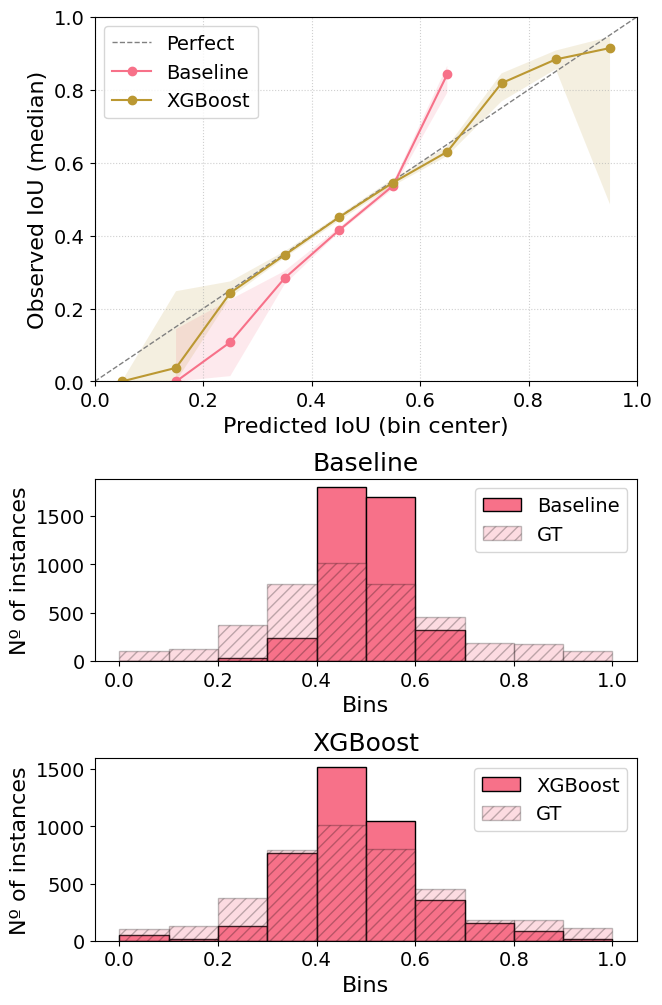

In [138]:
fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["xgb"],ax=ax_cal,label="XGBoost", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(iou_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_baseline,alpha=0.25, label="GT", fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")
ax_rf = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(iou_assessor_results["xgb"], ax=ax_rf, label="XGBoost", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_rf, alpha=0.25,label="GT", fillcolor="C0", fill="///")
ax_rf.set_title("XGBoost")

plt.savefig(f"./plots/{model}_iou_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

## LRP

/tmp/ipykernel_1434682/171404125.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


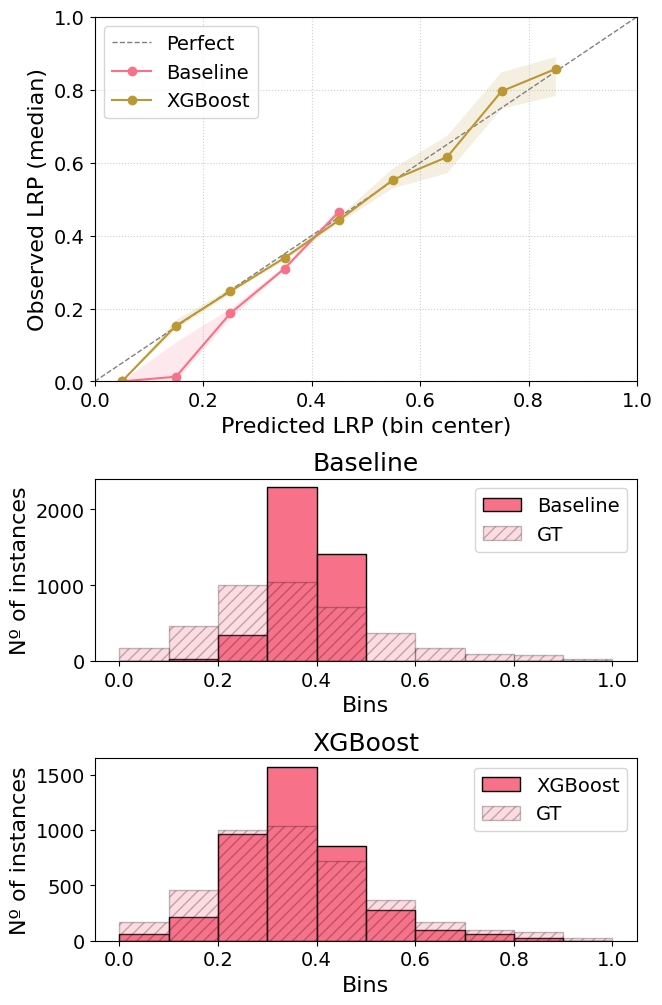

In [139]:
fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(lrp_assessor_results["GT"], lrp_assessor_results["baseline"], ax=ax_cal, label="Baseline", metric="LRP")
plot_calibration_curve(lrp_assessor_results["GT"], lrp_assessor_results["xgb"], ax=ax_cal, label="XGBoost", iden_line=False, metric="LRP")
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(lrp_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill="")
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_baseline, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")

ax_autg = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(lrp_assessor_results["xgb"], ax=ax_autg, label="XGBoost", fillcolor="C0", fill="")
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_autg, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_autg.set_title("XGBoost")

plt.tight_layout()
plt.savefig(f"./plots/{model}_lrp_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

# AUROC

For the AUROC we need to discretize the task to binary by setting a treshold. This is not ideal as we are deleting information. So not very useful. 

In [140]:
def plot_auroc(y_true_iou, y_pred, threshold=0.5, ax=None, label=None):
    y_true_iou = np.asarray(y_true_iou)
    y_pred = np.asarray(y_pred)
    success = (y_true_iou > threshold).astype(int)

    fpr, tpr, _ = roc_curve(success, y_pred)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.plot(fpr, tpr, label=label or f'AUROC = {roc_auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    return ax, roc_auc

## IoU

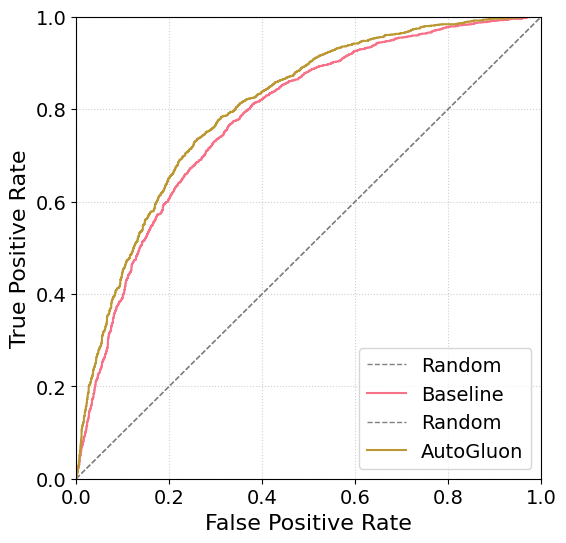

In [141]:
fig, ax = plt.subplots(figsize=(6, 6))
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["baseline"], threshold=0.5, ax=ax, label="Baseline")
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["autg"], threshold=0.5, ax=ax, label="AutoGluon")
ax.legend()